# Task 1 — Environment, Data Acquisition, and Exploratory Data Analysis

## Objective
This notebook loads the Bike Sharing dataset, performs data cleaning and quality checks, explores the structure of the data, and carries out exploratory data analysis (EDA).

## Inputs
- `../data/raw/hour.csv`

## Outputs
- `../data/cleaned.csv`
- exported figures in `../reports/`

## Notes
This notebook uses the Bike Sharing Dataset and prepares the cleaned dataset for Task 2.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Paths
DATA_FILE = Path("../data/raw/hour.csv")
CLEANED_FILE = Path("../data/cleaned.csv")
REPORTS_DIR = Path("../reports")

# Create reports directory if it does not exist
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Plot settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Dataset Information

**Dataset name:** Bike Sharing Dataset  
**Source:** Kaggle / original UCI Bike Sharing Dataset  
**License:** Add the exact license from the dataset page  
**Description:**  
This dataset contains hourly records of bike rental demand together with seasonal, weather, and calendar-related information. It was chosen because it is large enough for machine learning, includes both environmental and time-based features, and is suitable for exploratory analysis, supervised learning, clustering, and ensemble modeling.

In [3]:
df = pd.read_csv(DATA_FILE)
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (17379, 17)

Columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


## Feature Overview

The dataset contains hourly bike rental observations.

Key columns:
- `instant`: record index
- `dteday`: date
- `season`: season of the year
- `yr`: year indicator
- `mnth`: month
- `hr`: hour of the day
- `holiday`: whether the day is a holiday
- `weekday`: day of the week
- `workingday`: whether it is a working day
- `weathersit`: weather situation
- `temp`: normalized temperature
- `atemp`: normalized feeling temperature
- `hum`: normalized humidity
- `windspeed`: normalized wind speed
- `casual`: number of casual users
- `registered`: number of registered users
- `cnt`: total number of bike rentals

The target variable for the later supervised task will be `cnt`.

In [7]:
missing_values = df.isna().sum()
duplicates = df.duplicated().sum()

print("Missing values by column:")
print(missing_values)

print("\nNumber of duplicate rows:", duplicates)

Missing values by column:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Number of duplicate rows: 0


## Data Cleaning Decisions

The dataset will be cleaned before further analysis.

Cleaning choices:
- `instant` will be removed because it is only an index-like identifier.
- `dteday` will be removed because the dataset already includes extracted time-related columns such as year, month, and weekday.
- `casual` and `registered` will be removed because they directly sum to the target variable `cnt`, which would cause target leakage in later predictive modeling.
- Missing values and duplicate rows are checked before cleaning.

In [8]:
df_clean = df.copy()

columns_to_drop = ["instant", "dteday", "casual", "registered"]
df_clean = df_clean.drop(columns=columns_to_drop)

df_clean.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [9]:
print("Cleaned shape:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

Cleaned shape: (17379, 13)

Remaining columns:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


In [10]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   yr          17379 non-null  int64  
 2   mnth        17379 non-null  int64  
 3   hr          17379 non-null  int64  
 4   holiday     17379 non-null  int64  
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  int64  
 7   weathersit  17379 non-null  int64  
 8   temp        17379 non-null  float64
 9   atemp       17379 non-null  float64
 10  hum         17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9)
memory usage: 1.7 MB


In [11]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['season',
 'yr',
 'mnth',
 'hr',
 'holiday',
 'weekday',
 'workingday',
 'weathersit',
 'temp',
 'atemp',
 'hum',
 'windspeed',
 'cnt']

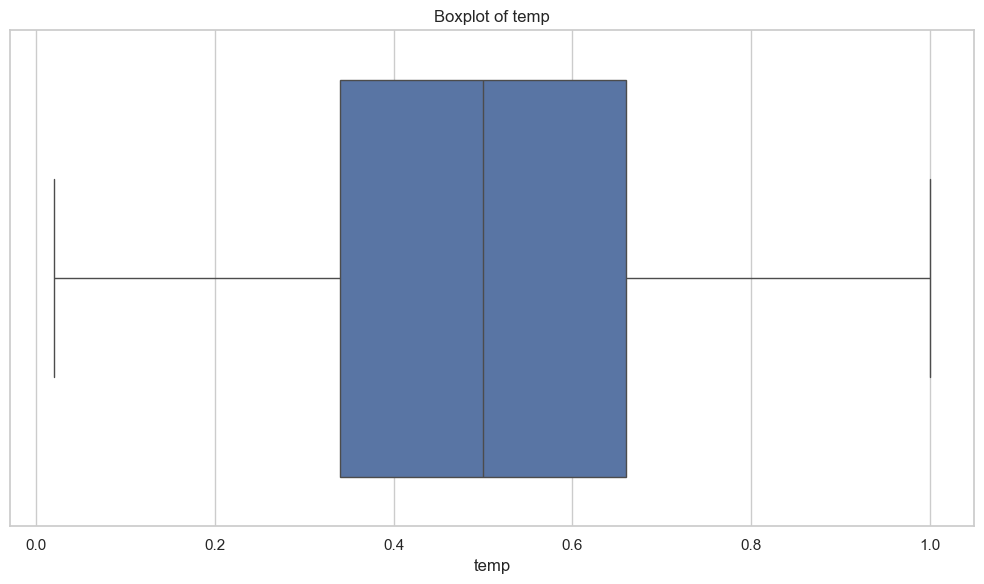

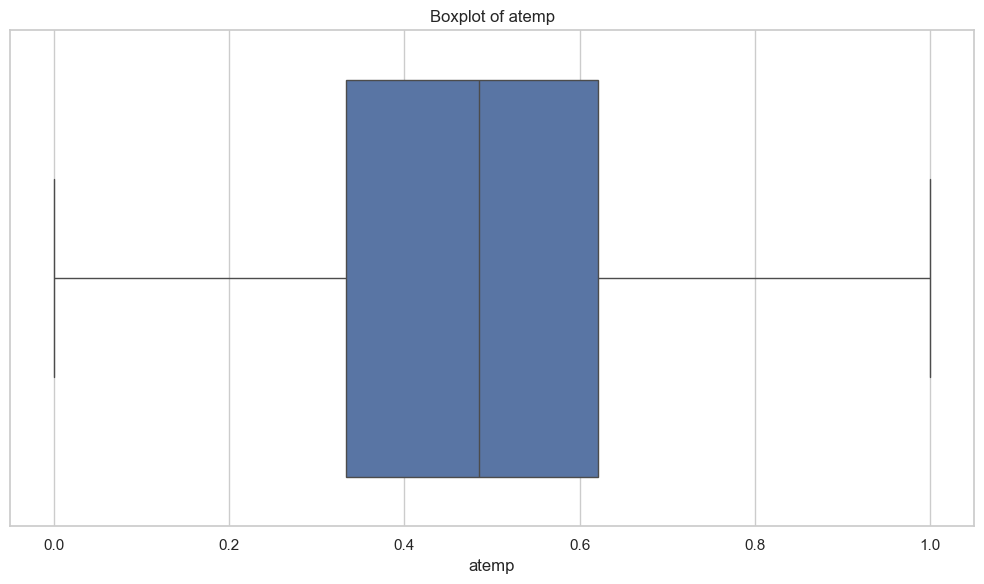

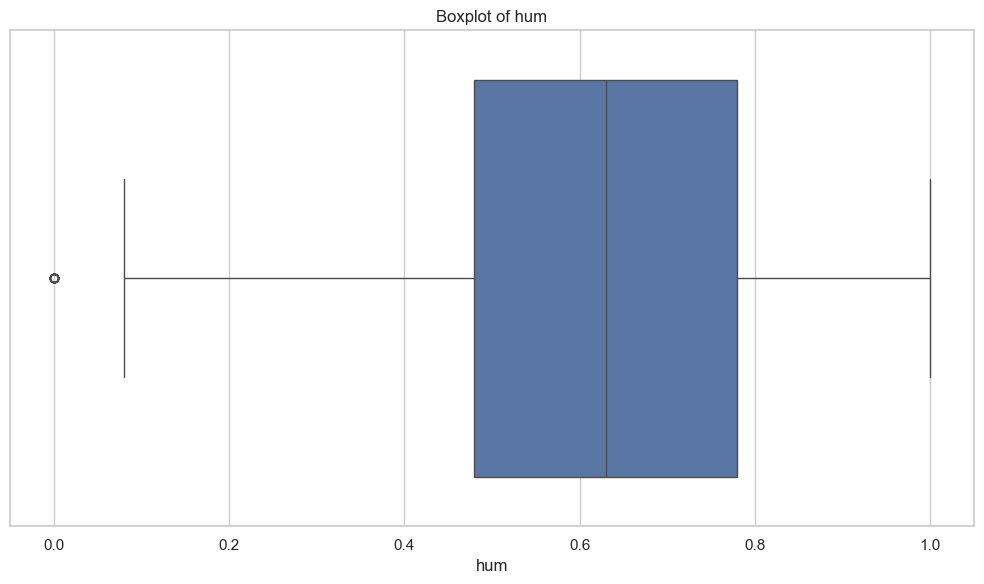

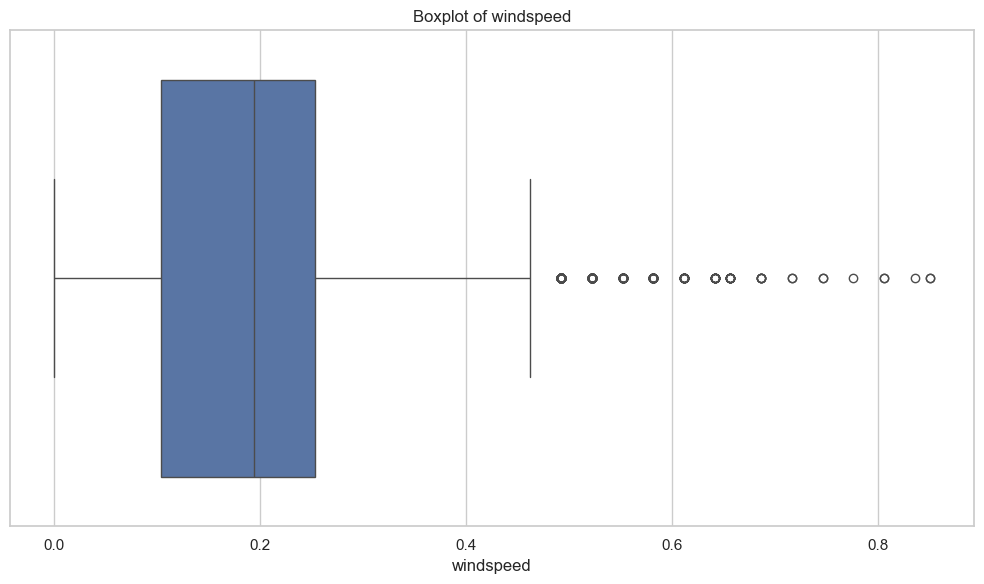

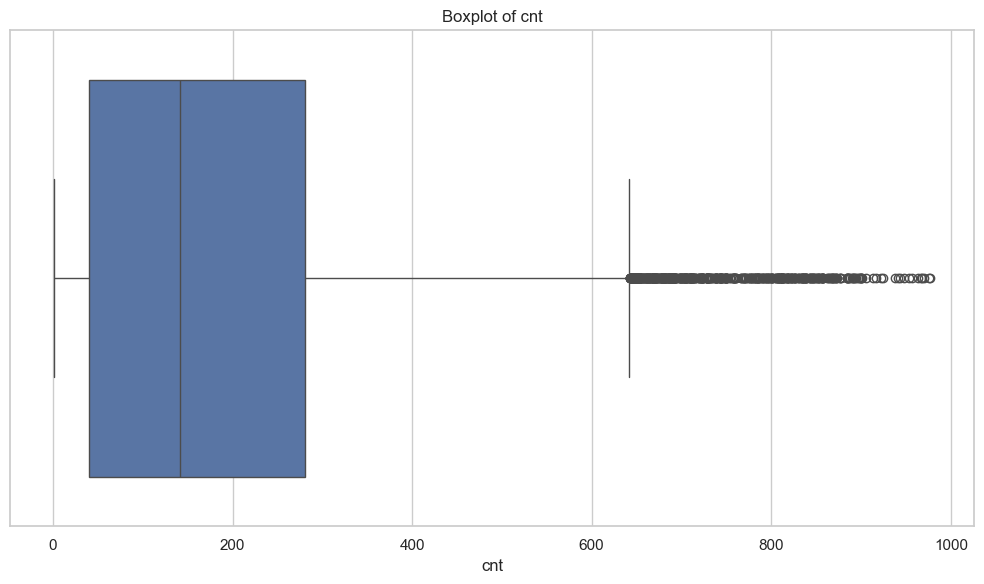

In [12]:
selected_boxplot_cols = ["temp", "atemp", "hum", "windspeed", "cnt"]

for col in selected_boxplot_cols:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## Outlier Review

Boxplots were used to inspect possible outliers in the main numeric features.  
For this dataset, unusual values may reflect real-world high-demand or low-demand periods rather than data-entry errors. Therefore, outliers should be interpreted carefully and not automatically removed.

## Visualization 1 — Distribution of Bike Rental Demand

**Question:** How is the target variable `cnt` distributed across hourly observations?

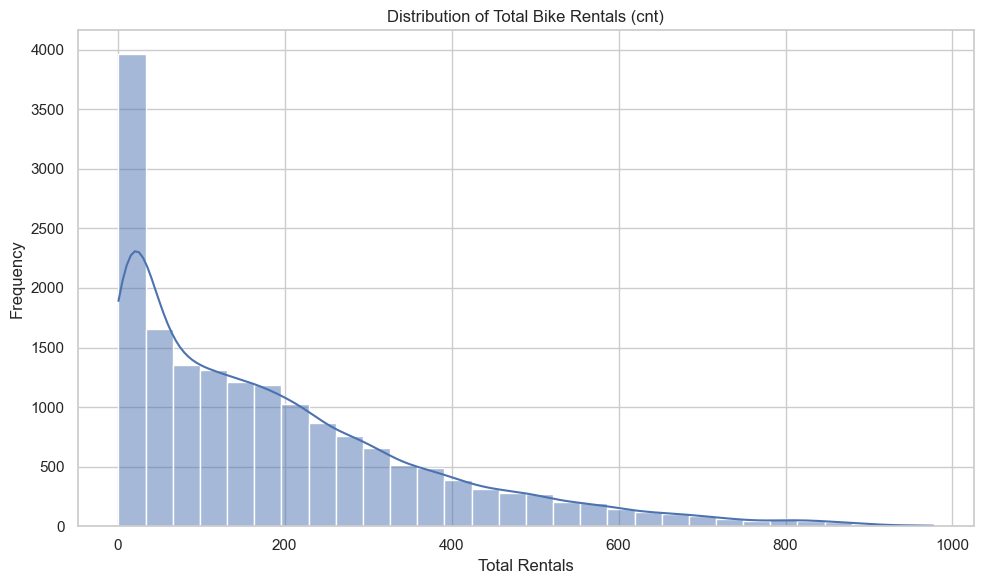

In [13]:
plt.figure()
sns.histplot(df_clean["cnt"], bins=30, kde=True)
plt.title("Distribution of Total Bike Rentals (cnt)")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "t1_distribution_cnt.png", dpi=300)
plt.show()

## Visualization 2 — Bike Rentals by Hour

**Question:** How does bike rental demand change over the course of the day?

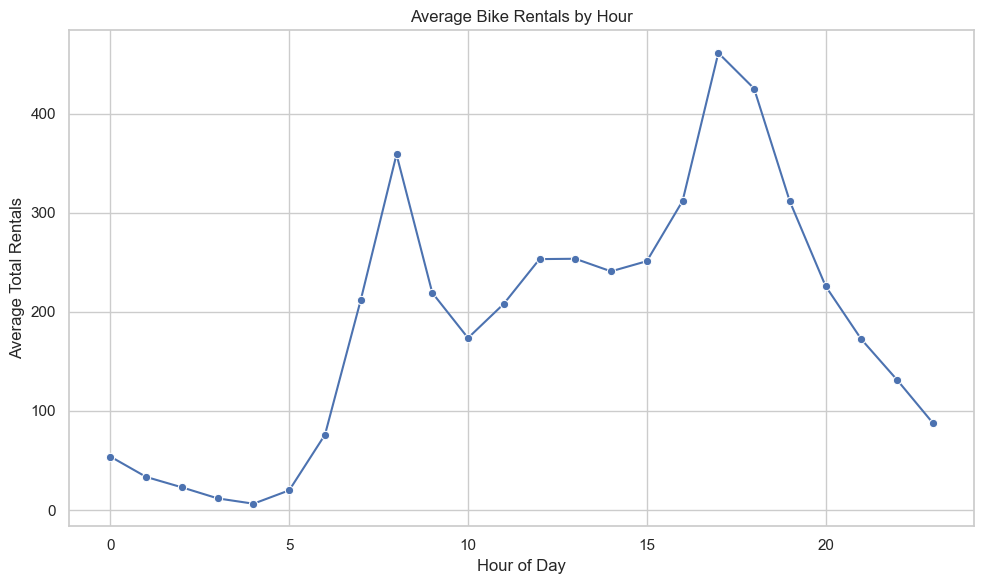

In [14]:
hourly_avg = df_clean.groupby("hr")["cnt"].mean().reset_index()

plt.figure()
sns.lineplot(data=hourly_avg, x="hr", y="cnt", marker="o")
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Rentals")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "t1_avg_cnt_by_hour.png", dpi=300)
plt.show()

## Visualization 3 — Demand by Season

**Question:** Does bike rental demand differ across seasons?

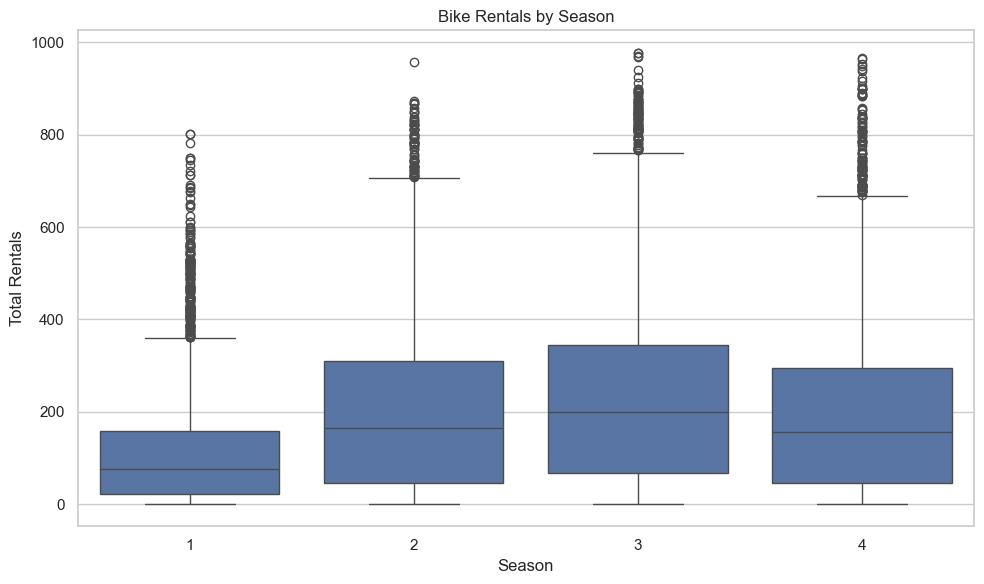

In [15]:
plt.figure()
sns.boxplot(data=df_clean, x="season", y="cnt")
plt.title("Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Total Rentals")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "t1_cnt_by_season.png", dpi=300)
plt.show()

## Visualization 4 — Demand by Weather Situation

**Question:** How do different weather conditions affect bike rental demand?

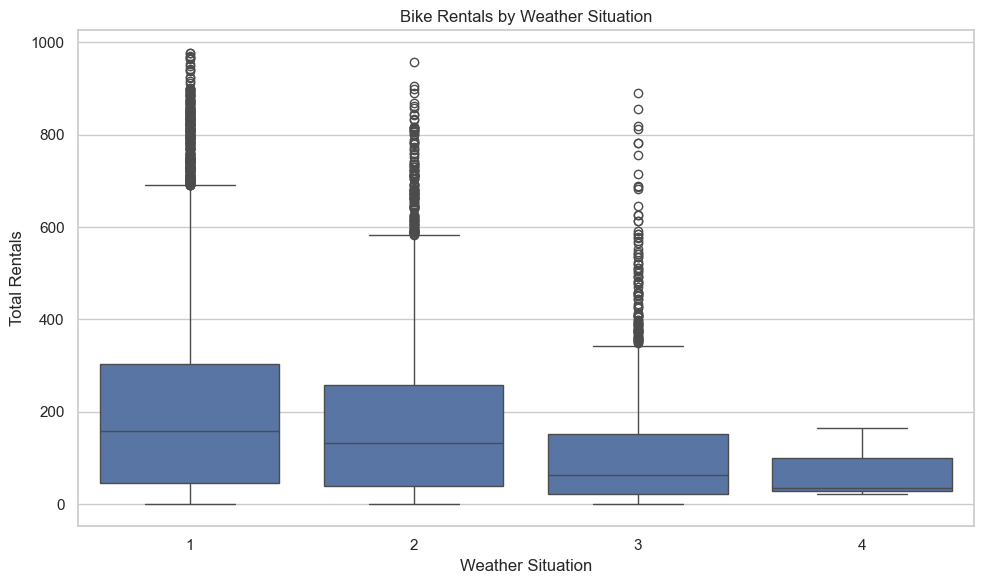

In [16]:
plt.figure()
sns.boxplot(data=df_clean, x="weathersit", y="cnt")
plt.title("Bike Rentals by Weather Situation")
plt.xlabel("Weather Situation")
plt.ylabel("Total Rentals")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "t1_cnt_by_weather.png", dpi=300)
plt.show()

## Visualization 5 — Temperature and Bike Rentals

**Question:** Is there a relationship between temperature and the number of bike rentals?

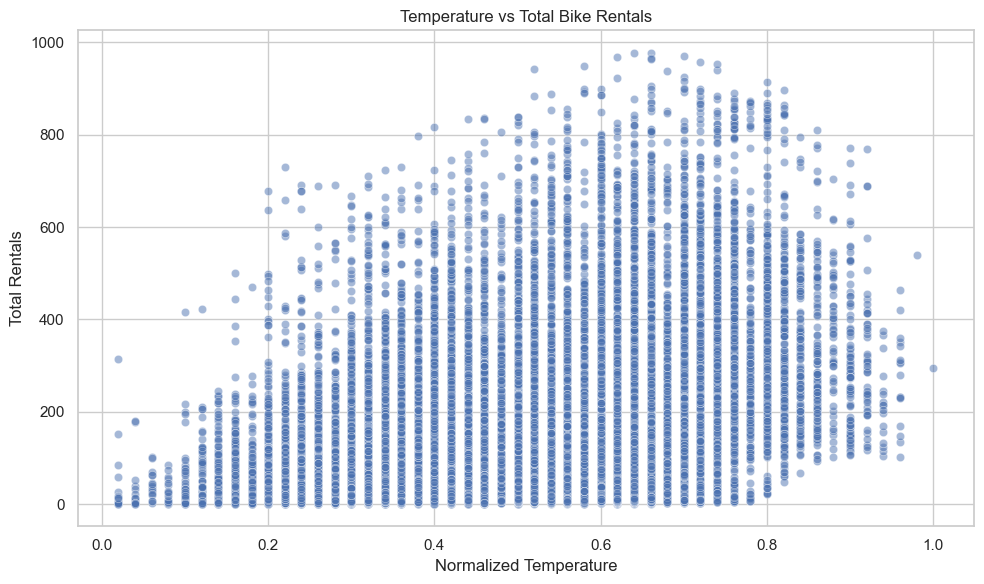

In [17]:
plt.figure()
sns.scatterplot(data=df_clean, x="temp", y="cnt", alpha=0.5)
plt.title("Temperature vs Total Bike Rentals")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Rentals")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "t1_temp_vs_cnt.png", dpi=300)
plt.show()

## Summary

The exploratory analysis showed that bike rental demand varies considerably depending on time-related and weather-related factors. The number of rentals appears to change across hours of the day, suggesting strong daily usage patterns. Seasonal and weather differences also seem to influence demand, with some conditions associated with much lower rental activity.

One notable observation is that demand is not evenly distributed: some time periods have very low activity, while others have much higher rental counts. This suggests that temporal variables such as hour, season, and working day may play an important role in prediction. Weather-related variables such as temperature and humidity also appear to have meaningful relationships with demand.

A key modeling question that remains is which features contribute most strongly to predicting bike rental counts and whether more advanced machine learning methods can significantly improve performance over simple baseline models.

In [18]:
df_clean.to_csv(CLEANED_FILE, index=False)
print(f"Cleaned dataset saved to: {CLEANED_FILE}")

Cleaned dataset saved to: ../data/cleaned.csv


In [19]:
check_df = pd.read_csv(CLEANED_FILE)
check_df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [20]:
print("Saved cleaned shape:", check_df.shape)

Saved cleaned shape: (17379, 13)
